In [107]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import PIL.Image as Image
import os
import cv2
import math
import torch

In [108]:
path = "PH2Dataset\PH2 Dataset images"

N = 200

In [109]:
def uniform_sampling(contour, n):
    contour = np.asarray(contour, dtype=np.float32)

    if not np.allclose(contour[0], contour[-1]):
        contour = np.vstack([contour, contour[0]])

    # Segmentvektoren + Längen
    seg = np.diff(contour, axis=0)
    seg_len = np.linalg.norm(seg, axis=1)

    # kumulative Bogenlänge
    s = np.concatenate([[0], np.cumsum(seg_len)])

    # Zielpositionen
    t = np.linspace(0, s[-1], n, endpoint=False)

    # Segmentindex
    idx = np.searchsorted(s, t, side='right') - 1
    idx = np.clip(idx, 0, len(seg)-1)

    # lokale Interpolation
    local_t = (t - s[idx]) / seg_len[idx]

    return contour[idx] + seg[idx] * local_t[:, None]

In [110]:
def calculate_points(size=N, noise_std=0.0):
    """
    noise_std: Standardabweichung des Gaußschen Rauschens in Pixeln (0.0 = kein Rauschen)
    """
    Points_Dict = {}
    Ground_Truth_Dict = {}
    image_Dict = {}

    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)

        if os.path.isdir(folder_path):
            bmp_files = []
            for root, _, files in os.walk(folder_path):
                for file in files:
                    if file.lower().endswith(".bmp"):
                        bmp_files.append(os.path.join(root, file))

            if len(bmp_files) >= 2:
                img1 = np.array(Image.open(bmp_files[0]).convert("RGB"))
                img2 = np.array(Image.open(bmp_files[1]).convert("L"))

                mask = (img2 > 0).astype(np.uint8) * 255
                contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
                contour = max(contours, key=cv2.contourArea).squeeze()

                sampled_points = uniform_sampling(contour, size)

                # ── Rauschen hinzufügen ──
                if noise_std > 0.0:
                    H, W = img1.shape[:2]
                    noise = np.random.normal(0, noise_std, sampled_points.shape)
                    sampled_points = sampled_points + noise
                    # Punkte innerhalb des Bildes halten
                    sampled_points[:, 0] = np.clip(sampled_points[:, 0], 0, W - 1)
                    sampled_points[:, 1] = np.clip(sampled_points[:, 1], 0, H - 1)

                shuffled = sampled_points.copy()
                np.random.shuffle(shuffled)

                Points_Dict[folder] = shuffled
                Ground_Truth_Dict[folder] = contour
                image_Dict[folder] = img1

    return Points_Dict, Ground_Truth_Dict, image_Dict

Points_Dict, Ground_Truth_Dict, image_Dict = calculate_points(size=200)

In [111]:
def plot_points(images_dict, points_dict, step=None):

    img = images_dict
    points = np.asarray(points_dict)

    plt.figure(figsize=(6, 6))

    # RGB oder Graustufe anzeigen
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)

        # Punkte plotten
    plt.scatter(
            points[:, 0],
            points[:, 1],
            c="red",
            s=20,
            zorder=10
        )

    plt.title(f"{step} – {len(points)} Punkte")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [112]:
def plot_diffusion_steps(image, points, function, images_dict=None, points_dict=None):
    
    steps = list(range(0, 51, 10)) + list(range(100, 201, 50)) + list(range(300, 999, 100))
    steps = sorted(set(steps))
    
    h, w = image.shape[:2]
    points_norm = (points / np.array([w, h])) * 2 - 1

    n = len(steps)
    cols = 5
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for i, t in enumerate(steps):
        ax = axes[i]

        if t == 0:
            noisy_points_np = points_norm
        else:
            # Torch-Pfad
            points_tensor = torch.tensor(points_norm, dtype=torch.float32).unsqueeze(0)  # (1, 200, 2)
            t_tensor = torch.tensor([t])
            
            noisy_norm, _ = function(points_tensor, t_tensor)
            
            # Zurück zu numpy
            noisy_points_np = noisy_norm.squeeze(0).numpy()  # (200, 2)
            #noisy_points_np = np.clip(noisy_points_np, -1, 1)

        noisy_points = (noisy_points_np + 1) / 2 * np.array([w, h])

        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(image)

        ax.scatter(noisy_points[:, 0], noisy_points[:, 1], c="red", s=10, zorder=10)
        ax.set_title(f"t={t}", fontsize=10)
        ax.axis("off")
        #ax.set_xlim(0, w)
        #ax.set_ylim(h, 0)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Forward Diffusion Process", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


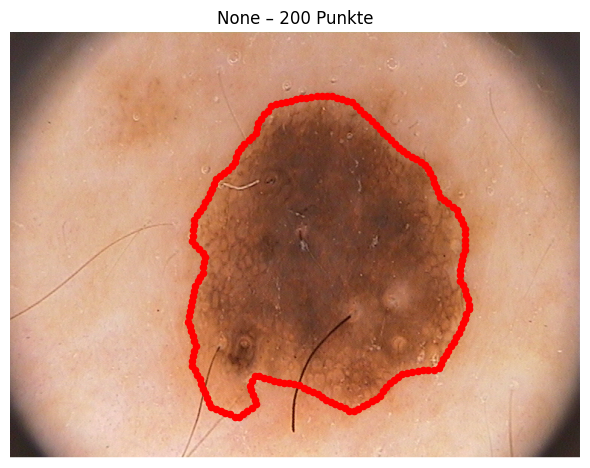

In [113]:
Points_Dict.keys()

plot_points(images_dict=image_Dict.get("IMD002"), points_dict=Points_Dict.get("IMD002"))

## Forward Process

In [114]:
T = 1000
betas = np.linspace(0.0001, 0.02, T)

# Jetzt berechnen wir das alpha_bar Array ein einziges Mal für alle Schritte
alphas = 1.0 - betas

#print(alphas)
alphas_bar = np.cumprod(alphas)

print(alphas_bar[:2], "...")

[0.9999     0.99978009] ...


In [115]:
def forward_process_uniform(X, t):
    _alpha_bar = alphas_bar[t]
    
    #X = np.clip(X, -1, 1)  # ← sicherstellen dass Input in [-1, 1]
    # Bei hohem t: Punkte sollen uniform über [-1,1] verteilt sein
    # Uniform-Rauschen hat keine "Ausreißer" wie Gauß
    epsilon = np.random.uniform(-1, 1, size=X.shape)
    
    mean = np.sqrt(_alpha_bar) * X
    noise = np.sqrt(1.0 - _alpha_bar) * epsilon
    
    noisy_points = mean + noise
    
    # Sanfter Clip als Sicherheitsnetz
    #noisy_points = np.clip(noisy_points, -1, 1)
    
    return noisy_points, epsilon

In [116]:
def forward_process_gauss(X, t, sigma=0.5):  # sigma steuert die Breite der Glocke
    _alpha_bar = alphas_bar[t]
    #X = np.clip(X, -1, 1)  # ← sicherstellen dass Input in [-1, 1]
    epsilon = np.random.randn(*X.shape) * sigma  # ← enger als N(0,1)
    
    mean = np.sqrt(_alpha_bar) * X
    noise = np.sqrt(1.0 - _alpha_bar) * epsilon
    
    noisy_points = mean + noise
    # noisy_points = np.clip(noisy_points, -1, 1)
    return noisy_points, epsilon

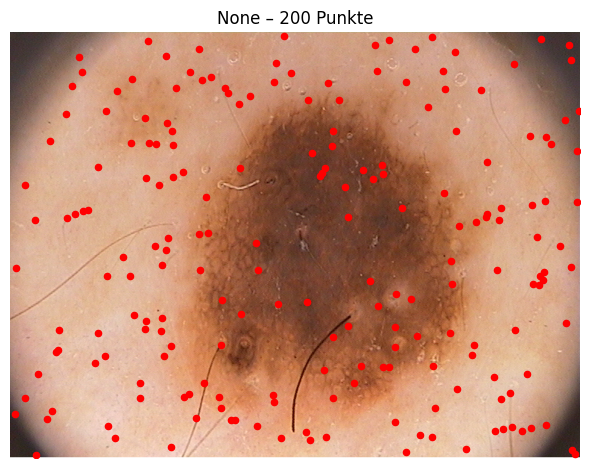

In [117]:
image = image_Dict.get("IMD002") 
points = Points_Dict.get("IMD002")

h, w = image.shape[:2]

# Normalisiere auf [-1, 1]
points_norm = (points / np.array([w, h])) * 2 - 1

noisy_norm, _ = forward_process_uniform(points_norm, 900)

# Zurück in Bildkoordinaten, clip nur als Sicherheitsnetz
#noisy_norm = np.clip(noisy_norm, -1, 1)
noisy_points = (noisy_norm + 1) / 2 * np.array([w, h])

plot_points(image, noisy_points)

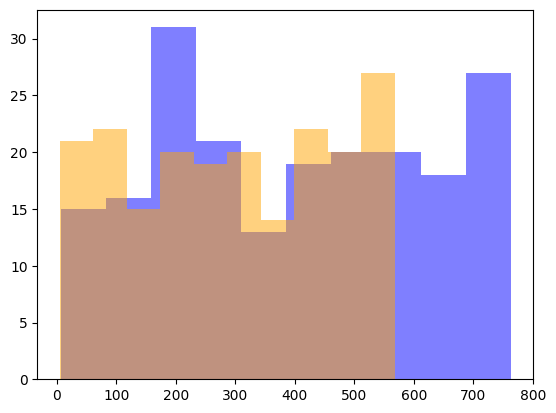

In [118]:
X = []
Y = []
for n in noisy_points:
    X.append(n[0])
    Y.append(n[1])

plt.hist(X, alpha=0.5, color="blue");
plt.hist(Y, alpha=0.5, color="orange");

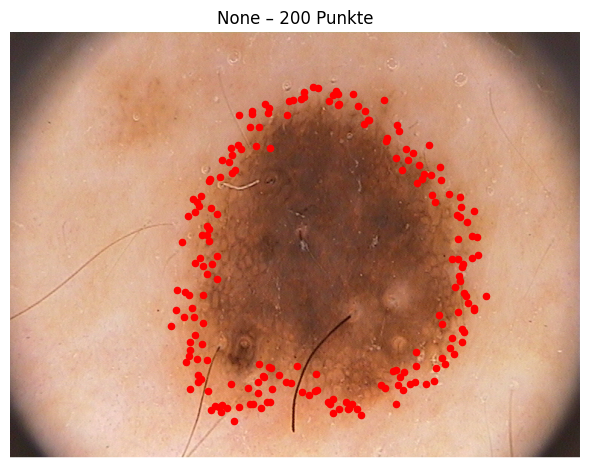

In [119]:
image = image_Dict.get("IMD002") 
points = Points_Dict.get("IMD002")

h, w = image.shape[:2]

# Normalisiere auf [-1, 1]
points_norm = (points / np.array([w, h])) * 2 - 1

noisy_norm, _ = forward_process_gauss(points_norm, 30, sigma=0.3)

# Zurück in Bildkoordinaten, clip nur als Sicherheitsnetz
#noisy_norm = np.clip(noisy_norm, -1, 1)
noisy_points = (noisy_norm + 1) / 2 * np.array([w, h])

plot_points(image, noisy_points)

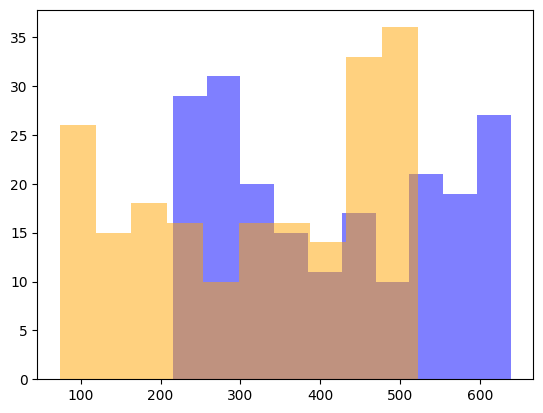

In [120]:
X = []
Y = []
for n in noisy_points:
    X.append(n[0])
    Y.append(n[1])

plt.hist(X, alpha=0.5, color="blue");
plt.hist(Y, alpha=0.5, color="orange");

C:\Users\Tsyri\AppData\Local\Temp\ipykernel_11624\3618877114.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  noisy_points = mean + noise


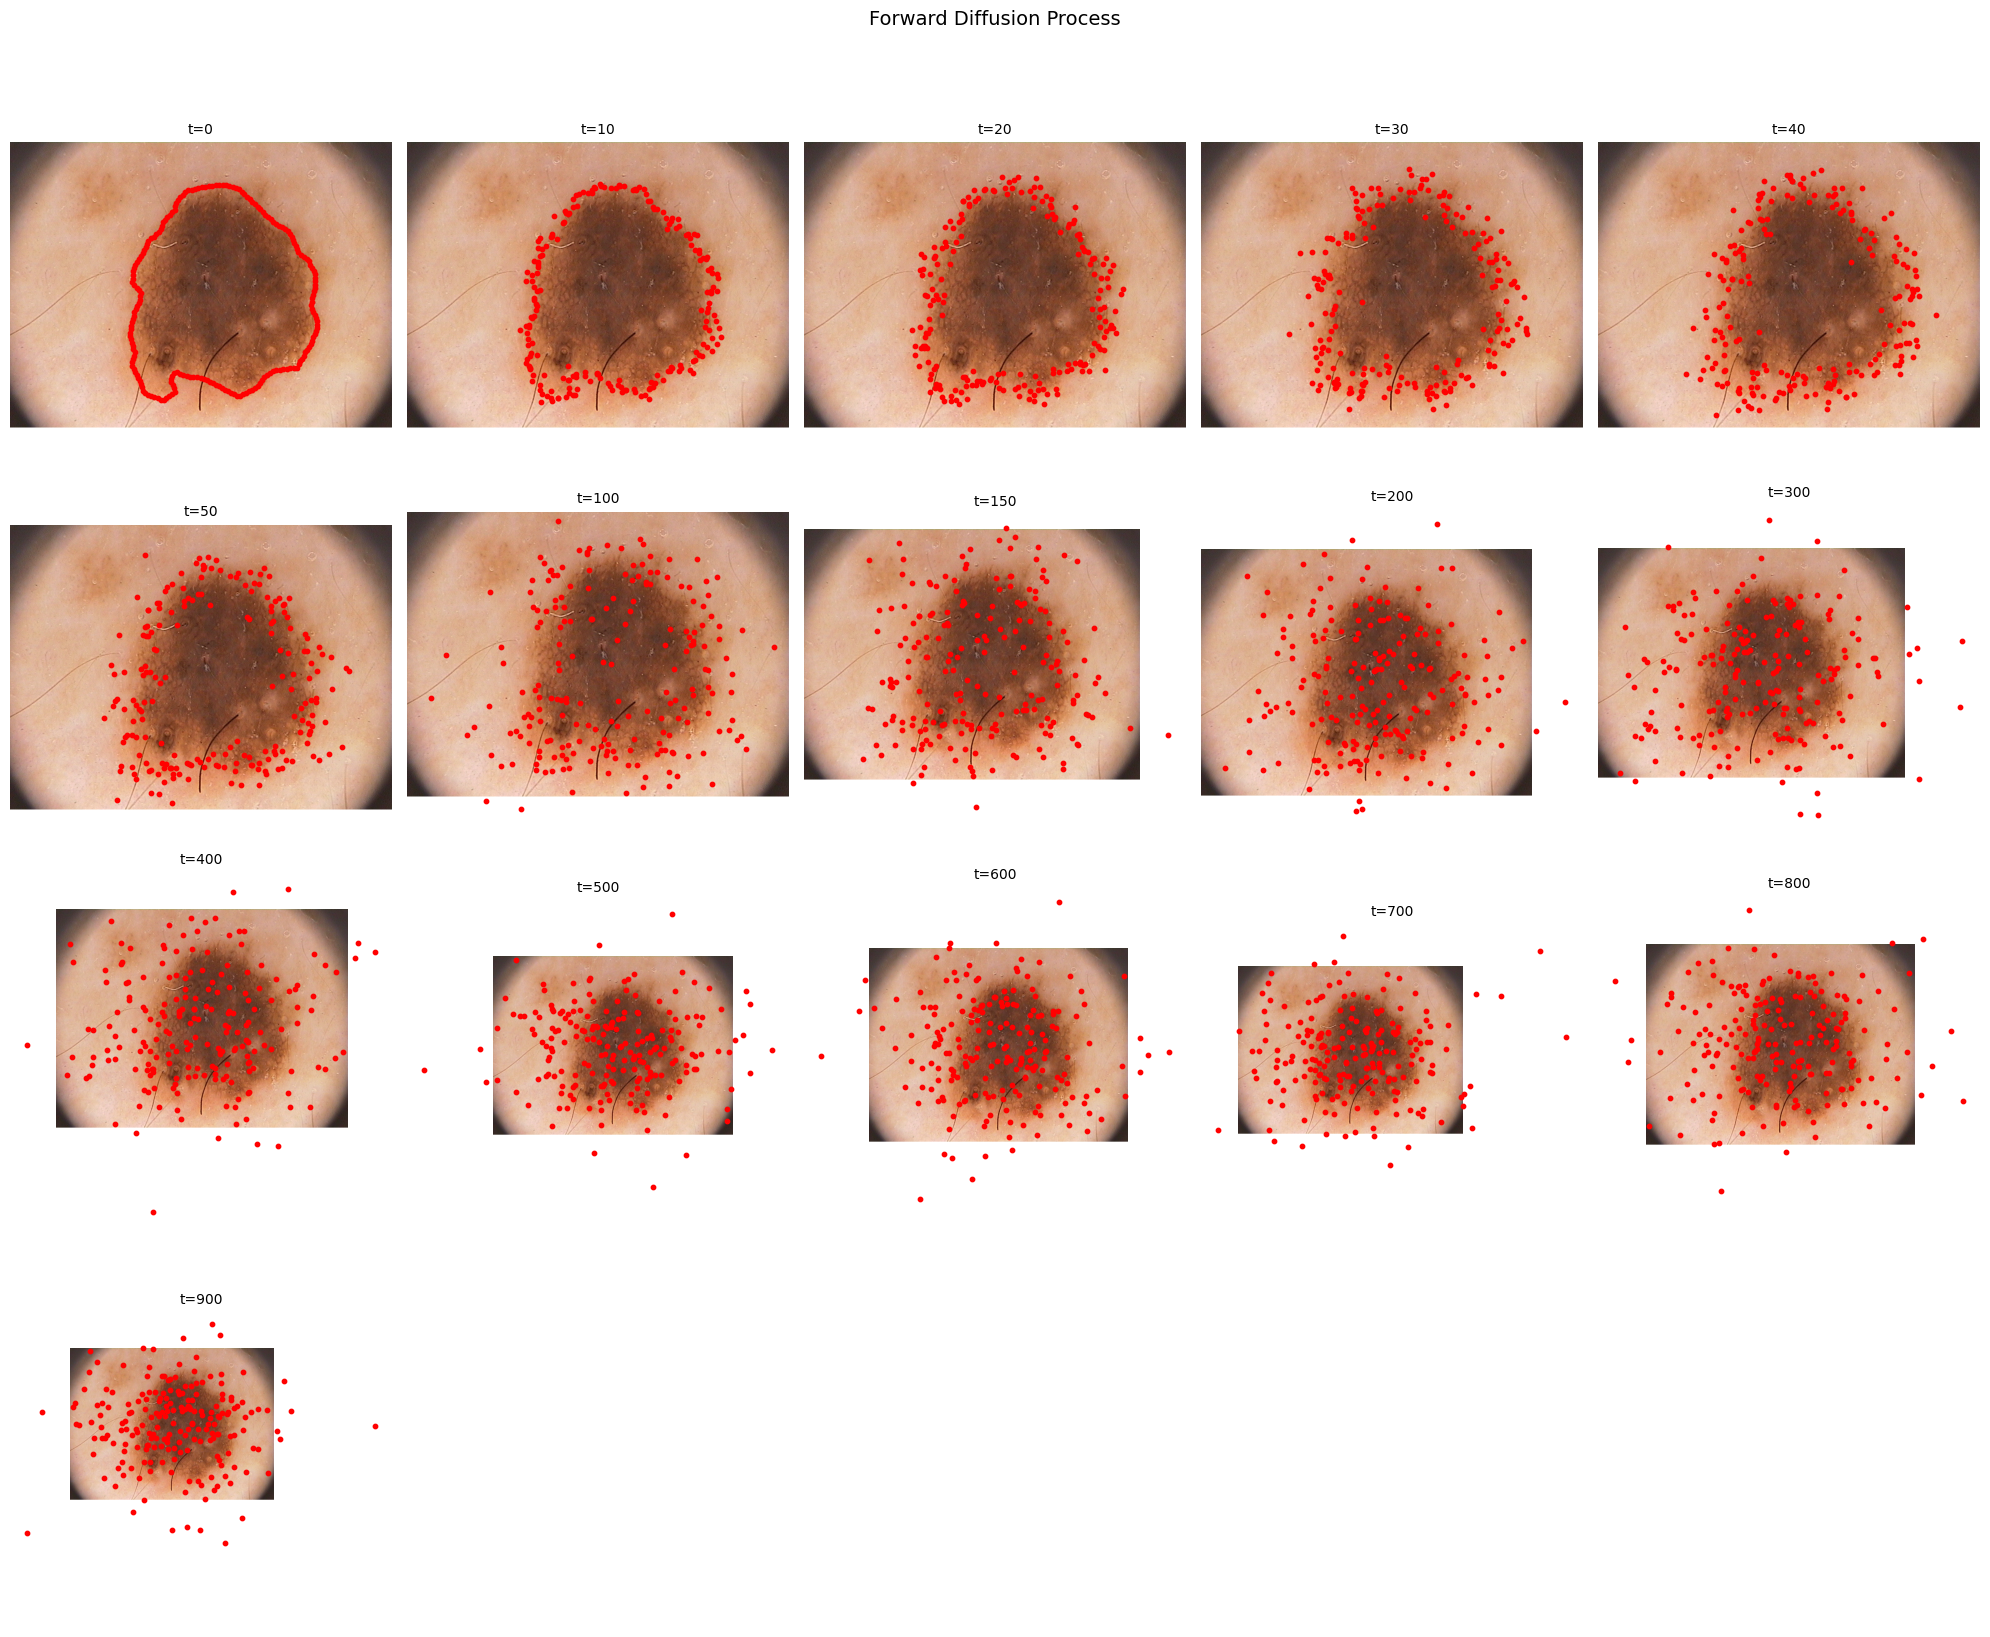

In [121]:
# Aufruf
image = image_Dict.get("IMD002")
points = Points_Dict.get("IMD002")
plot_diffusion_steps(image, points, function=forward_process_gauss)

C:\Users\Tsyri\AppData\Local\Temp\ipykernel_11624\3083264187.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  noisy_points = mean + noise


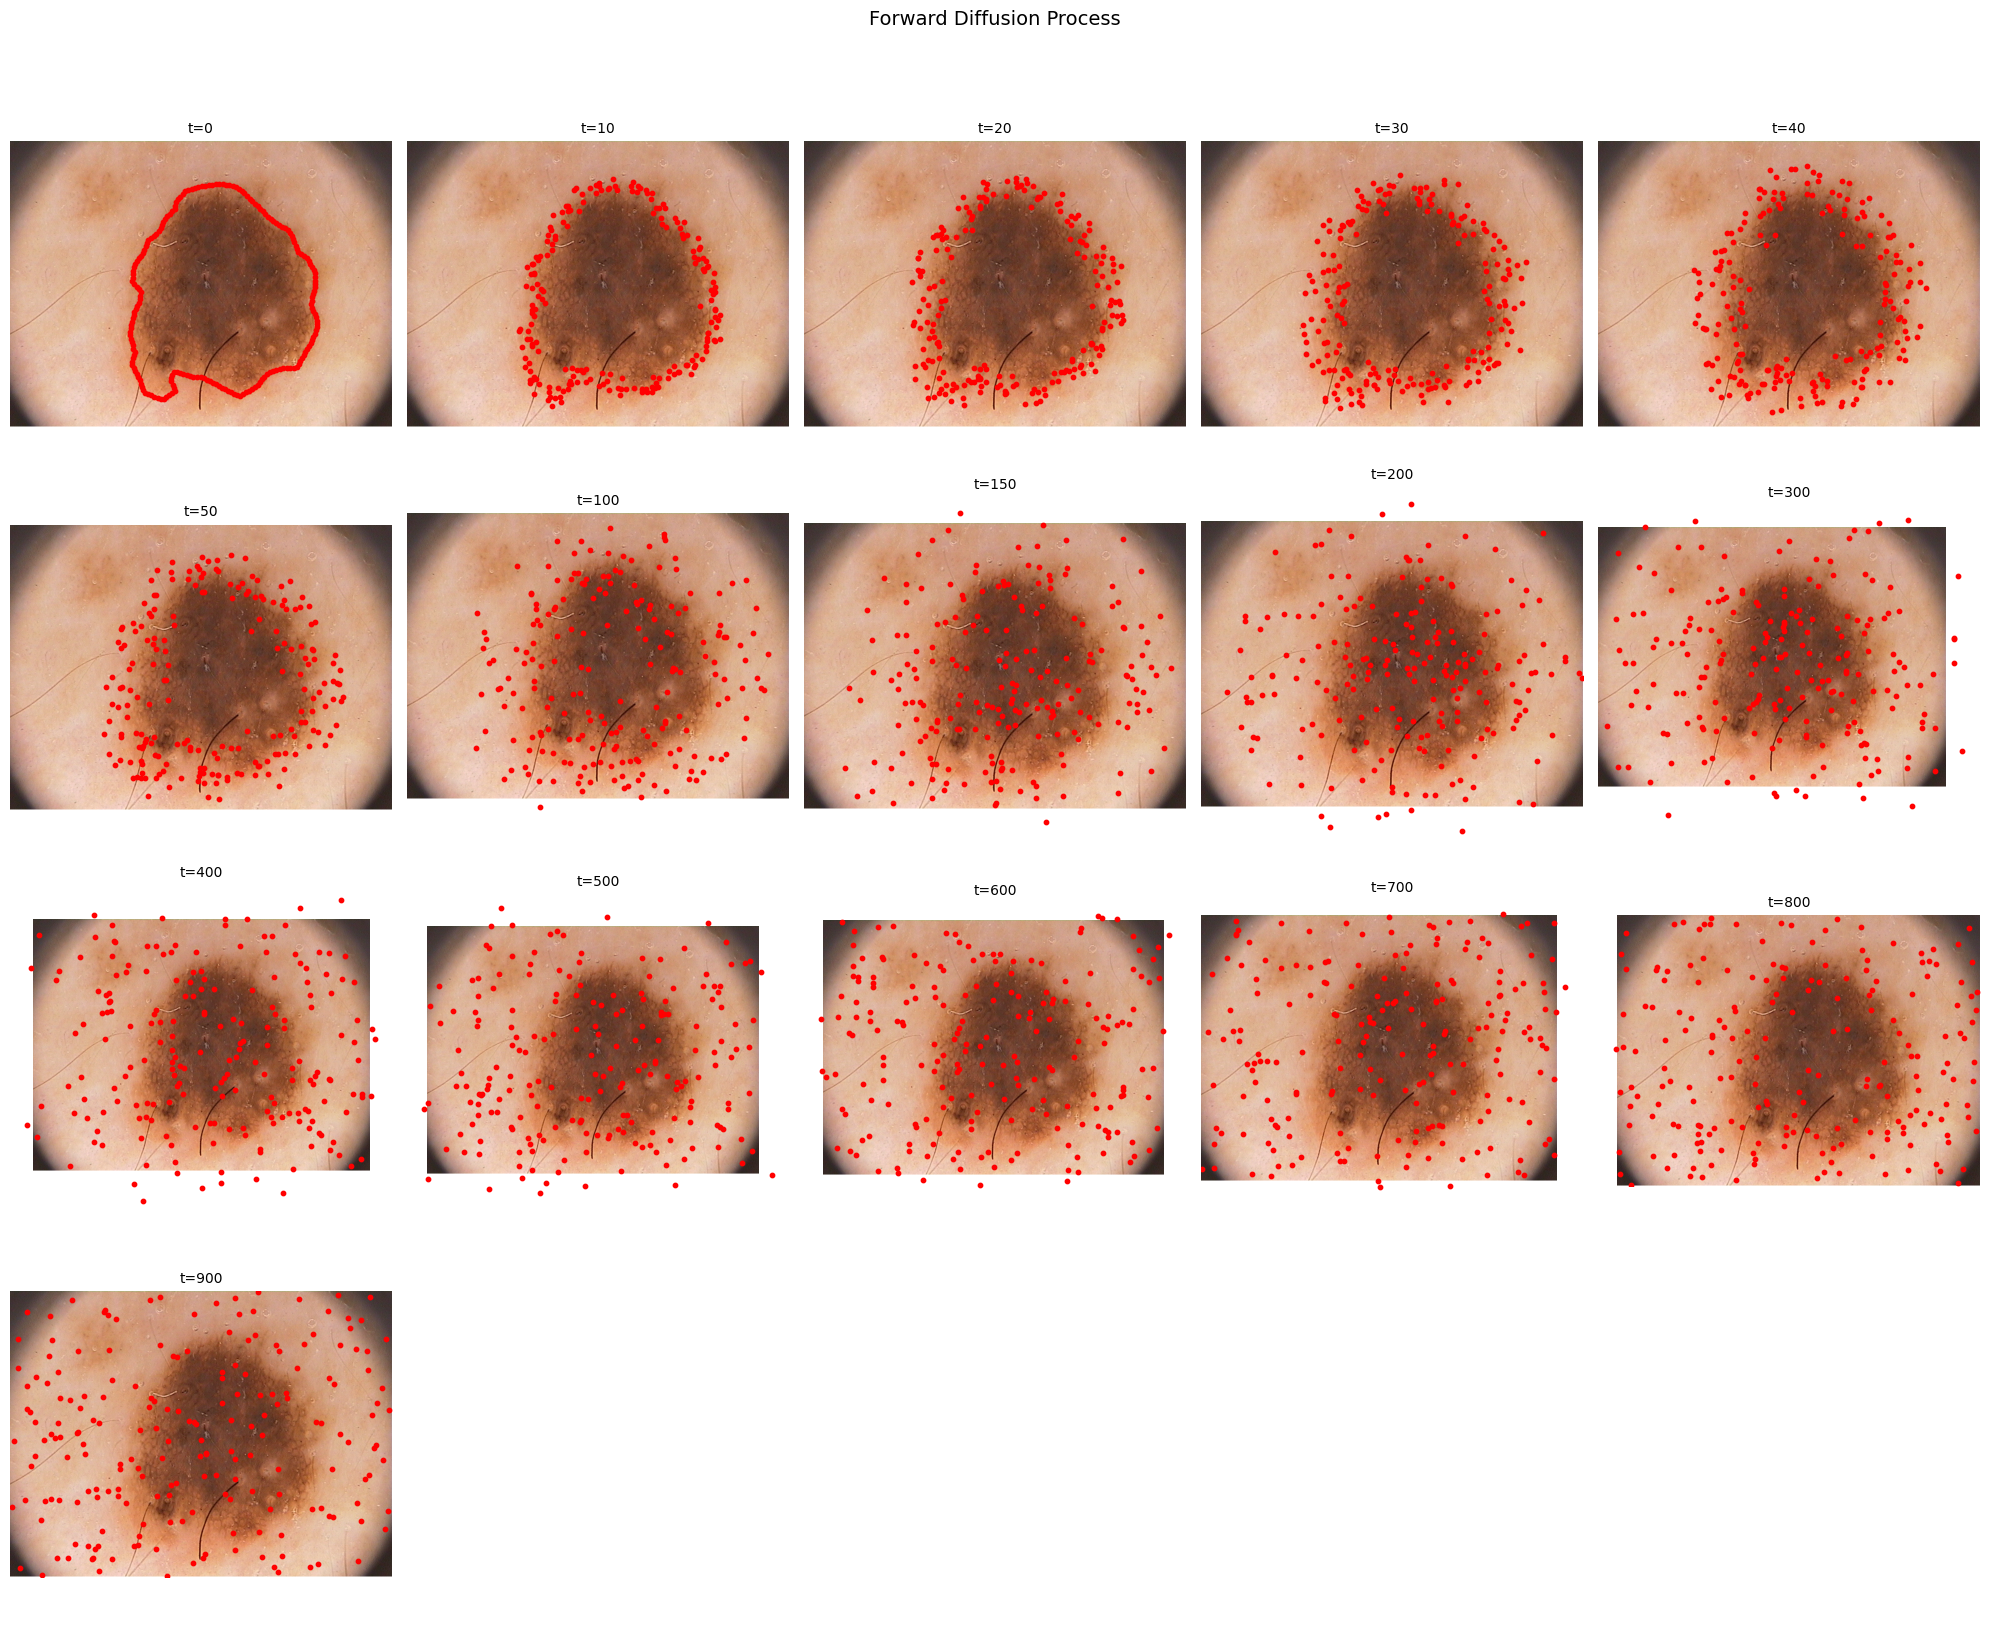

In [122]:
image = image_Dict.get("IMD002")
points = Points_Dict.get("IMD002")
plot_diffusion_steps(image, points, function=forward_process_uniform)

In [123]:
class Sampler:
    def __init__(self, num_steps=1000, beta_start=0.0001, beta_end=0.02, noise_sigma=1):
        self.num_steps = num_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.noise_sigma = noise_sigma  # ← neu

        self.beta_schedule = self.linear_beta_schedule()
        self.alpha = 1 - self.beta_schedule
        self.alpha_cumprod = torch.cumprod(self.alpha, dim=-1)
        
    def linear_beta_schedule(self):
        return torch.linspace(self.beta_start, self.beta_end, self.num_steps)
    
    def _repeated_unsqueeze(self, target, tensor):
        while target.dim() < tensor.dim():
            target = target.unsqueeze(1)
        return target
    
    def add_noise(self, image, timesteps):
        device = image.device
        alpha_cumulative_prod_timesteps = self.alpha_cumprod[timesteps].to(device)

        mean_coeff = alpha_cumulative_prod_timesteps.sqrt() 
        var_coeff = (1 - alpha_cumulative_prod_timesteps).sqrt()

        noise = torch.randn_like(image) * self.noise_sigma  # ← sigma hier

        mean_coeff = self._repeated_unsqueeze(mean_coeff, image)
        var_coeff = self._repeated_unsqueeze(var_coeff, image)

        noise_image = mean_coeff * image + var_coeff * noise 

        return noise_image, noise
    
    def remove_noise(self, image, timesteps, predicted_noise):
        device = image.device
        equal_to_zero_mask = (timesteps == 0)
    
        beta_t = self.beta_schedule[timesteps].to(device)
        alpha_t = self.alpha[timesteps].to(device)
        alpha_cumprod_t = self.alpha_cumprod[timesteps].to(device)
    
        safe_timesteps = torch.clamp(timesteps - 1, min=0)
        alpha_cumprod_prev_t = self.alpha_cumprod[safe_timesteps].to(device)
        alpha_cumprod_prev_t[equal_to_zero_mask] = 1.0
    
        noise = torch.randn_like(image)
    
        variance = beta_t * (1 - alpha_cumprod_prev_t) / (1 - alpha_cumprod_t)
        variance = self._repeated_unsqueeze(variance, image)
        variance = torch.sqrt(variance)
    
        sigma_t_z = variance * noise  # ✓ erst berechnen
    
        mask = (~equal_to_zero_mask).float()          # ✓ dann maskieren
        mask = self._repeated_unsqueeze(mask, image)
        sigma_t_z = sigma_t_z * mask                  # bei t=0 → 0
    
        noise_coefficient = beta_t / torch.sqrt(1 - alpha_cumprod_t)
        noise_coefficient = self._repeated_unsqueeze(noise_coefficient, image)
    
        reciprocal_root_a_t = alpha_t ** -0.5
        reciprocal_root_a_t = self._repeated_unsqueeze(reciprocal_root_a_t, image)
    
        mean = reciprocal_root_a_t * (image - (noise_coefficient * predicted_noise))
    
        denoised = mean + sigma_t_z
    
        return denoised

In [124]:
sampler = Sampler()

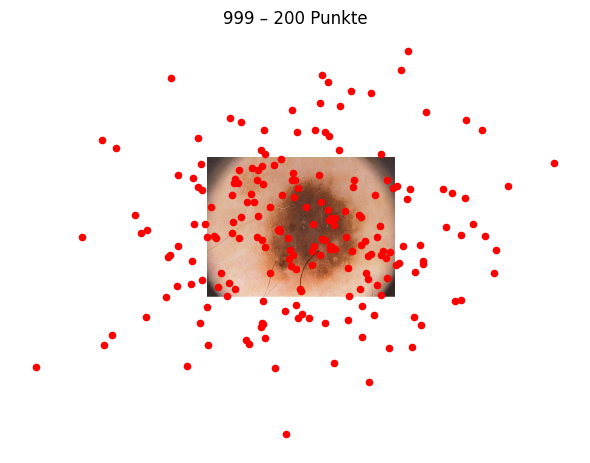

In [125]:
image = image_Dict.get("IMD002")
points = Points_Dict.get("IMD002")

h, w = image.shape[:2]

# Normalisieren auf [-1, 1]
points_norm = (np.clip(points, [0,0], [w,h]) / np.array([w, h])) * 2 - 1

# Zu Torch Tensor: (200, 2) → (1, 200, 2) für Batch-Dimension
points_tensor = torch.tensor(points_norm, dtype=torch.float32).unsqueeze(0)

# Timestep

step = 999

t = torch.tensor([step])

noisy_points, epsilon = sampler.add_noise(points_tensor, t)

# Zurück zu numpy für plot
noisy_np = noisy_points.squeeze(0).numpy()  # (200, 2)
noisy_final = (noisy_np + 1) / 2 * np.array([w, h])

plot_points(image, noisy_final, step=step)

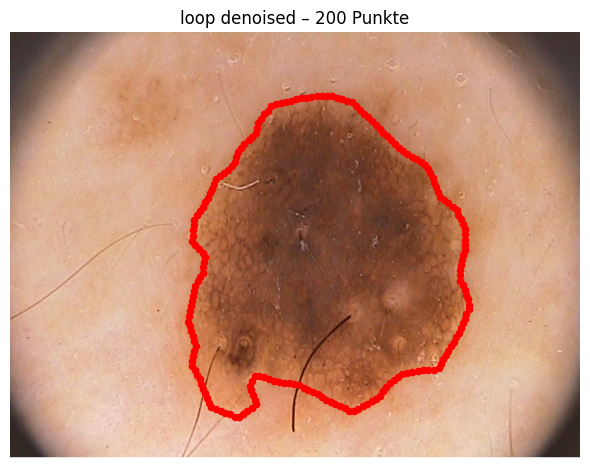

In [126]:
x = noisy_points.clone()


for step in reversed(range(sampler.num_steps)):  # 999 → 0
    t_tensor = torch.tensor([step])
    
    # "Oracle": berechne das echte epsilon für diesen x_t
    # x_t = sqrt(ā_t) * x0 + sqrt(1-ā_t) * ε  →  ε = (x_t - sqrt(ā_t)*x0) / sqrt(1-ā_t)
    alpha_cumprod_t = sampler.alpha_cumprod[step]
    oracle_epsilon = (x - alpha_cumprod_t.sqrt() * points_tensor) / (1 - alpha_cumprod_t).sqrt()
    
    x = sampler.remove_noise(x, t_tensor, oracle_epsilon)

denoised_np = x.squeeze(0).numpy()
denoised_final = (denoised_np + 1) / 2 * np.array([w, h])
plot_points(image, denoised_final, step="loop denoised")

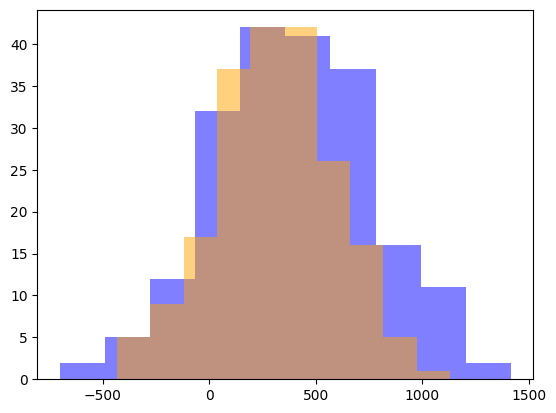

In [127]:
X = []
Y = []
for n in noisy_final:
    X.append(n[0])
    Y.append(n[1])

plt.hist(X, alpha=0.5, color="blue");
plt.hist(Y, alpha=0.5, color="orange");

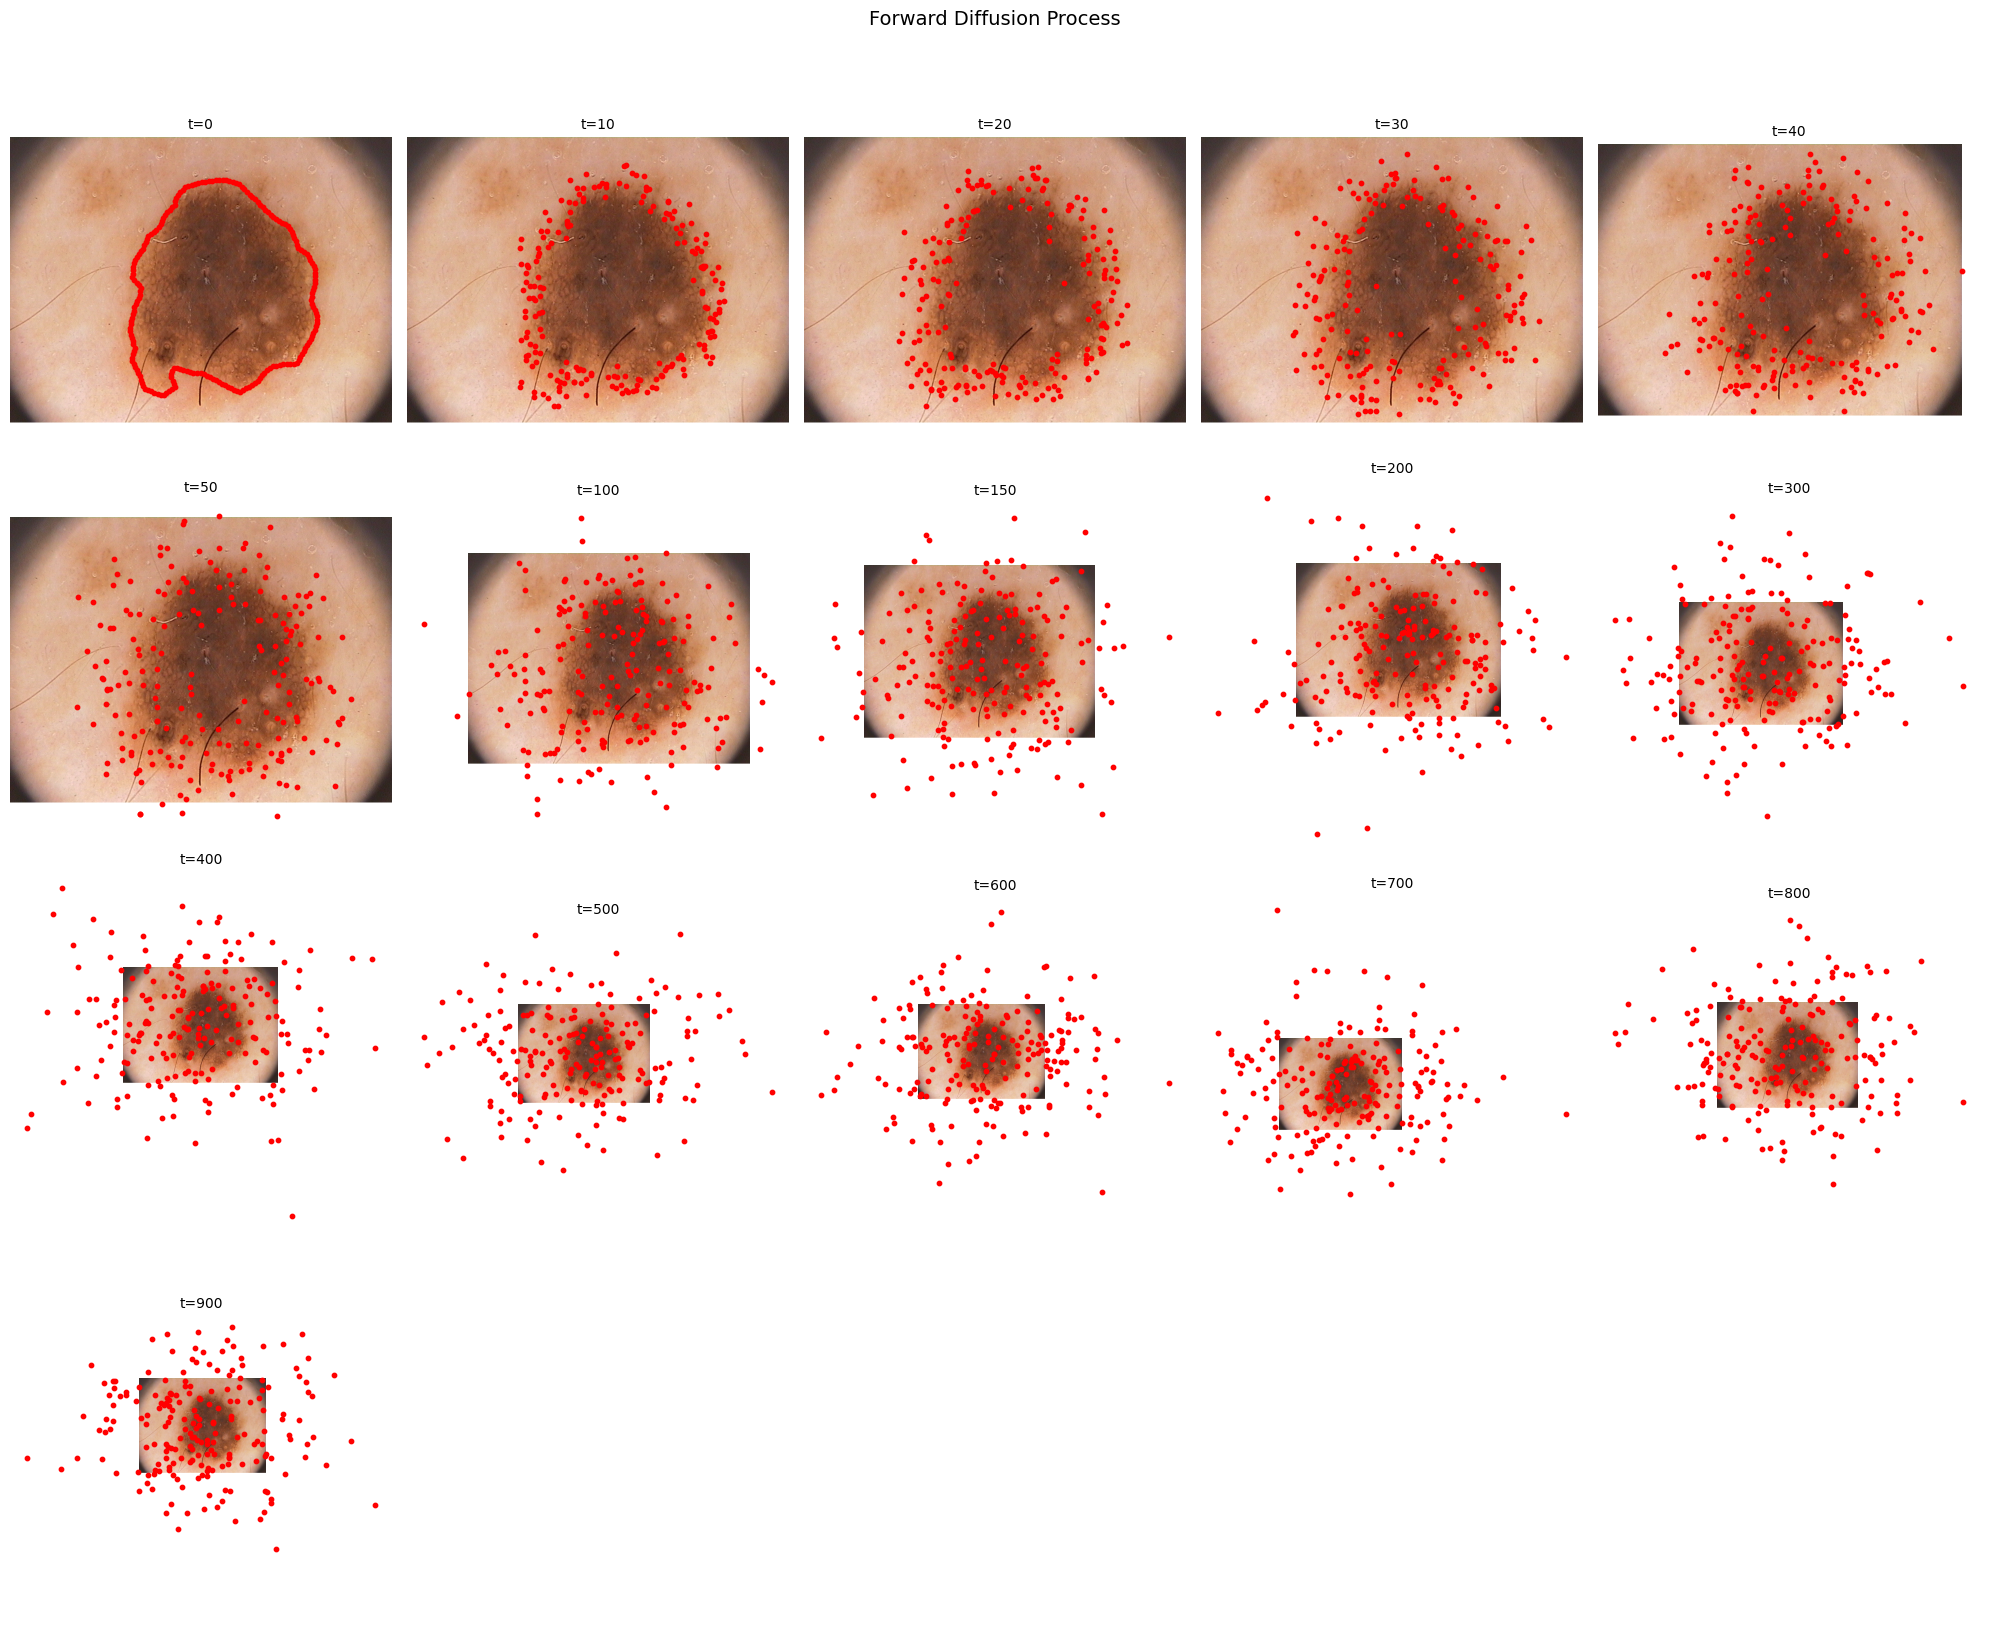

In [128]:
# Aufruf
image = image_Dict.get("IMD002")
points = Points_Dict.get("IMD002")
plot_diffusion_steps(image, points, function=sampler.add_noise)